In [1]:
import PeakCNN
import numpy as np
import matplotlib.pyplot as plt
import h5py
import tensorflow as tf

# Peak-CNN example

in this notebook we provide a simple example case that details how Peak-CNN can be trained and applied to an experiment. We have provided a small synthetic image dataset for testing purposes. Each snapshot contains the images from four cameras. Also included is OTF metadata in the form of 4 numbers for each camera as we have this readily available in our processing. At the end of the notebook is an example without such using data.

The test case provided here is not intended to showcase performance of the approach but just how to put the functions provided within PeakCNN into practice. Only a limited amount of snapshots is provided to keep the file size small.

In [2]:
#read provided synthetic data
def read_simdata(inname):
    alldata=[]
    with h5py.File(inname, 'r') as fin:
        for snapname,gsnap in fin.items():
            thissnapdata = []
            for camname, gcam in gsnap.items():
                thissnapdata.append([np.array(gcam["imagedata"]),np.array(gcam["otfdata"]),np.array(gcam["true_uvs"])])
            alldata.append(thissnapdata)
    return alldata

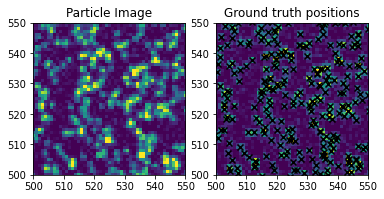

In [3]:
alldata = read_simdata('datatest.hdf5')

img=alldata[0][1][0]
gt_uvs =alldata[0][1][2]

plt.subplot(1, 2, 1)
plt.imshow(img,clim=(0,500))
plt.xlim(500,550)
plt.ylim(500,550)
plt.title("Particle Image")

plt.subplot(1, 2, 2)
plt.imshow(img,clim=(0,500))
plt.scatter(gt_uvs[:,0],gt_uvs[:,1],marker="x",color="black")
plt.xlim(500,550)
plt.ylim(500,550)
plt.title("Ground truth positions");

## Data preparation

In order to train the model we need to tile the image data as well as transform the ground truth peak coordinate positions into the internal representation for the model.
Here we use a generator that is later then passed to tensorflow.

In [4]:
#generator to feed trainingdata from read in datastructure to tensorflow
def tfdatagenerator(filedata):
    for persnapshotdata in filedata:
        for percameradata in persnapshotdata:
            
            imagedata, otfdata, groundtruth = percameradata
            imgsize = imagedata.shape 
            labeldata = PeakCNN.obtain_internal_representation(groundtruth,imgsize)
            
            #reshape to tensorflow BWHC ordering
            imagedata = imagedata.reshape(1,*imgsize,1)
            labeldata = labeldata.reshape(1,*imgsize,3)
            
            tiledimagedata, tx,ty = PeakCNN.create_tiling(imagedata)
            tiledlabeldata, tx,ty = PeakCNN.create_tiling(labeldata)
            
            otfdata = otfdata.reshape(1,1,4) # we have a constant otf here so no need to tile otf data
            
            #yield individual tiles
            for i in np.random.permutation(tiledimagedata.shape[0]):
                yield {"imagedata":tiledimagedata[i],"metadata":otfdata},  tiledlabeldata[i]


The loading functions need to be adjusted to fit ones data format. The model expects Tensorflow Dataset input matching the output_signature below.

In [5]:
#use first snapshot as validation data and rest for training
filevaldata = tf.data.Dataset.from_generator(lambda : tfdatagenerator(alldata[:1]),
                                        output_signature=(
                                            {"imagedata":  tf.TensorSpec(shape=(256,256,1), dtype=tf.float32),
                                             "metadata": tf.TensorSpec(shape=(1,1,4), dtype=tf.float32),
                                            }
                                                ,
                                            tf.TensorSpec(shape=(256,256,3), dtype=tf.float32)
                                            )
                                        )


filetraindata = tf.data.Dataset.from_generator(lambda : tfdatagenerator(alldata[1:]),
                                                output_signature=(
                                                    {"imagedata":  tf.TensorSpec(shape=(256,256,1), dtype=tf.float32),
                                                     "metadata": tf.TensorSpec(shape=(1,1,4), dtype=tf.float32),
                                                    }
                                                        ,
                                                    tf.TensorSpec(shape=(256,256,3), dtype=tf.float32)
                                                    )
                                                )



In [6]:
#we use mixed precision mode for greater training speed here, needs to be disabled if not supported by hardware
#tf.keras.mixed_precision.set_global_policy('mixed_float16')

model = PeakCNN.build_model(metadatashape=(1,1,4))

#add some metrics to observe training progress
metrics =[[], #metrics for subxyloss
          [ #metrics for classloss
    PeakCNN.Precision(from_logits=True), # precision at prob threshold=0.5
    PeakCNN.Recall(from_logits=True),
    PeakCNN.AUC(from_logits=True),
    PeakCNN.PrecisionAtRecall(True,0.8) #precision value at 80% recall
]
]

model.compile(optimizer = tf.keras.optimizers.Adam(learning_rate = 0.001), metrics = metrics, loss = PeakCNN.lossterm)

## Training
The model is then trained using a pipeline employing shuffling of the tiles followed by batching. For this small example we  can also switch on caching of the pipeline to make things go a bit quicker since the data fits into memory

In [7]:
trainpipeline = filetraindata.shuffle(600).batch(16).cache()
valpipeline = filevaldata.shuffle(300).batch(16).cache()
history=model.fit(trainpipeline,
                    validation_data = valpipeline,
                    epochs=30,
                  )

Epoch 1/30
32/32 [==============================] - 21s 206ms/step - loss: 0.8173 - output_subpx_loss: 0.3598 - output_class_loss: 0.4575 - output_class_precision: 0.0813 - output_class_recall: 0.1275 - output_class_auc: 0.7242 - output_class_precision_at_recall: 0.0687 - val_loss: 0.6893 - val_output_subpx_loss: 0.2426 - val_output_class_loss: 0.4467 - val_output_class_precision: 0.0000e+00 - val_output_class_recall: 0.0000e+00 - val_output_class_auc: 0.8288 - val_output_class_precision_at_recall: 0.0940
Epoch 2/30
32/32 [==============================] - 3s 91ms/step - loss: 0.4555 - output_subpx_loss: 0.1887 - output_class_loss: 0.2668 - output_class_precision: 0.9054 - output_class_recall: 0.0883 - output_class_auc: 0.9695 - output_class_precision_at_recall: 0.3959 - val_loss: 0.5407 - val_output_subpx_loss: 0.2070 - val_output_class_loss: 0.3337 - val_output_class_precision: 0.9482 - val_output_class_recall: 0.0630 - val_output_class_auc: 0.9774 - val_output_class_precision_at_rec

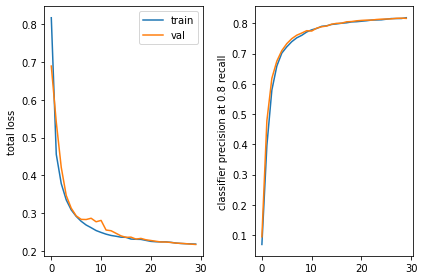

In [8]:
plt.subplot(1,2,1)
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.ylabel("total loss")
plt.legend(["train","val"])

plt.subplot(1,2,2)
plt.plot(history.history["output_class_precision_at_recall"])
plt.plot(history.history["val_output_class_precision_at_recall"])
plt.ylabel("classifier precision at 0.8 recall")

plt.tight_layout();

## Applying the model
Testing the model on validation data shows that even for a limited amount of training data we get reasonable results

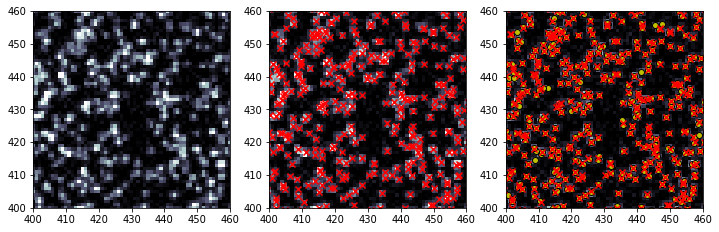

In [9]:
img=alldata[0][1][0]
otf =alldata[0][1][1]

c1,c2,npeaks = PeakCNN.do_PeakCNN(model,img,metadata=otf,threshold=0.5)

gt_uvs =alldata[0][1][2]

plt.figure(figsize=(12,8))
plt.subplot(1,3,1)
plt.imshow(img,clim=(0,500),cmap='bone')
#plt.scatter(gt_uvs[:,0],gt_uvs[:,1],marker="o",color="y")
#plt.scatter(c2,c1,marker="x",color="r")
plt.xlim(400,460)
plt.ylim(400,460)

plt.subplot(1,3,2)
plt.imshow(img,clim=(0,500),cmap='bone')
#plt.scatter(gt_uvs[:,0],gt_uvs[:,1],marker="o",color="y")
plt.scatter(c2,c1,marker="x",color="r")
plt.xlim(400,460)
plt.ylim(400,460)

plt.subplot(1,3,3)
plt.imshow(img,clim=(0,500),cmap='bone')
plt.scatter(gt_uvs[:,0],gt_uvs[:,1],marker="o",color="y",edgecolors='black')
plt.scatter(c2,c1,marker="x",color="r")
plt.xlim(400,460)
plt.ylim(400,460);

# PeakCNN example without OTF metadata

The example above used OTF metadata that was provided for this testcase.
Such additional information for the network can improve detection performance if for example the shape of the particle images vary betwen cameras or even spatially within a camera image.

But this is not a strong requirement for the method at all so if you have no such additional data simply omit this. The default behaviour of the functions is to assume no metadata

In [10]:
model_nometa = PeakCNN.build_model()  #or  PeakCNN.build_model(metadatashape=None)
model_nometa.compile(optimizer = tf.keras.optimizers.Adam(learning_rate = 0.001), metrics = metrics, loss = PeakCNN.lossterm)
history_nometa=model_nometa.fit(trainpipeline,
                    validation_data = valpipeline,
                    epochs=30,
                  )
# in this situation one normally would have a trainpipeline that does not supply a "metadata" output.
# here we are reusing the one from above for convinience so Tensorflow will warn us that there is an unused "metadata" input (as intended)

Epoch 1/30


/home/islander/godb_ph/TMP/PySTB3_venv/lib/python3.6/site-packages/keras/engine/functional.py:585: UserWarning: Input dict contained keys ['metadata'] which did not match any model input. They will be ignored by the model.
  [n for n in tensors.keys() if n not in ref_input_names])


32/32 [==============================] - 7s 119ms/step - loss: 0.7794 - output_subpx_loss: 0.3489 - output_class_loss: 0.4305 - output_class_output_class_precision: 0.1660 - output_class_output_class_recall: 0.2990 - output_class_output_class_auc: 0.8410 - output_class_output_class_precision_at_recall: 0.1061 - val_loss: 0.7284 - val_output_subpx_loss: 0.2795 - val_output_class_loss: 0.4489 - val_output_class_output_class_precision: 0.3448 - val_output_class_output_class_recall: 8.0724e-05 - val_output_class_output_class_auc: 0.6716 - val_output_class_output_class_precision_at_recall: 0.0578
Epoch 2/30
32/32 [==============================] - 3s 92ms/step - loss: 0.4370 - output_subpx_loss: 0.1834 - output_class_loss: 0.2536 - output_class_output_class_precision: 0.8858 - output_class_output_class_recall: 0.1169 - output_class_output_class_auc: 0.9709 - output_class_output_class_precision_at_recall: 0.4123 - val_loss: 0.5405 - val_output_subpx_loss: 0.2075 - val_output_class_loss: 0.33

Epoch 15/30
32/32 [==============================] - 3s 96ms/step - loss: 0.2306 - output_subpx_loss: 0.1245 - output_class_loss: 0.1062 - output_class_output_class_precision: 0.7952 - output_class_output_class_recall: 0.8079 - output_class_output_class_auc: 0.9937 - output_class_output_class_precision_at_recall: 0.8012 - val_loss: 0.2566 - val_output_subpx_loss: 0.1324 - val_output_class_loss: 0.1243 - val_output_class_output_class_precision: 0.8941 - val_output_class_output_class_recall: 0.6472 - val_output_class_output_class_auc: 0.9900 - val_output_class_output_class_precision_at_recall: 0.7949
Epoch 16/30
32/32 [==============================] - 3s 97ms/step - loss: 0.2284 - output_subpx_loss: 0.1232 - output_class_loss: 0.1052 - output_class_output_class_precision: 0.7953 - output_class_output_class_recall: 0.8106 - output_class_output_class_auc: 0.9937 - output_class_output_class_precision_at_recall: 0.8034 - val_loss: 0.2442 - val_output_subpx_loss: 0.1278 - val_output_class_lo

The perfomance will be essentially identical to the model with metadata for this simple testcase since the otf metadata we supplied is identical for all cameras so there is really no information to be obtained from it anyway.

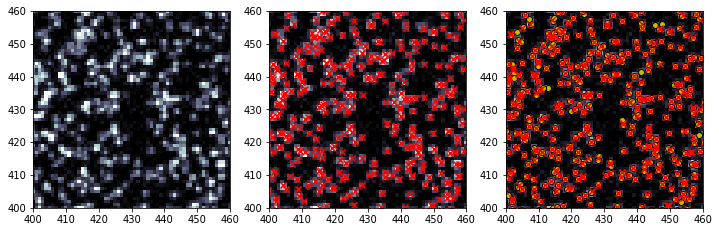

In [11]:
img=alldata[0][1][0]
otf =alldata[0][1][1]

c1,c2,npeaks = PeakCNN.do_PeakCNN(model_nometa,img,threshold=0.5) # or PeakCNN.do_PeakCNN(model,img,metadata=None,threshold=0.5)

gt_uvs =alldata[0][1][2]

plt.figure(figsize=(12,8))
plt.subplot(1,3,1)
plt.imshow(img,clim=(0,500),cmap='bone')
#plt.scatter(gt_uvs[:,0],gt_uvs[:,1],marker="o",color="y")
#plt.scatter(c2,c1,marker="x",color="r")
plt.xlim(400,460)
plt.ylim(400,460)

plt.subplot(1,3,2)
plt.imshow(img,clim=(0,500),cmap='bone')
#plt.scatter(gt_uvs[:,0],gt_uvs[:,1],marker="o",color="y")
plt.scatter(c2,c1,marker="x",color="r")
plt.xlim(400,460)
plt.ylim(400,460)

plt.subplot(1,3,3)
plt.imshow(img,clim=(0,500),cmap='bone')
plt.scatter(gt_uvs[:,0],gt_uvs[:,1],marker="o",color="y",edgecolors='black')
plt.scatter(c2,c1,marker="x",color="r")
plt.xlim(400,460)
plt.ylim(400,460);